In [1]:
import os
import shutil
import random

raw_dir = "../data/raw"
ann_dir = "../data/annotated"
train_dir = "../data/train"
val_dir = "../data/val"
test_dir = "../data/test"

images = [f for f in os.listdir(raw_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
random.shuffle(images)

train_split = int(len(images) * 0.8)
val_split = int(len(images) * 0.9)

for i, img_name in enumerate(images):
    if i < train_split:
        dest = train_dir
    elif i < val_split:
        dest = val_dir
    else:
        dest = test_dir
        
    shutil.copy(os.path.join(raw_dir, img_name), os.path.join(dest, img_name))
    
    xml_name = os.path.splitext(img_name)[0] + ".xml"
    if os.path.exists(os.path.join(ann_dir, xml_name)):
        shutil.copy(os.path.join(ann_dir, xml_name), os.path.join(dest, xml_name))

print("Split successful! Check the folders again.")

Split successful! Check the folders again.


Checking file: X00016469612.png
Extracted Data: {
  "CASHHHHHHHHHHHH": "CASH BILL"
}


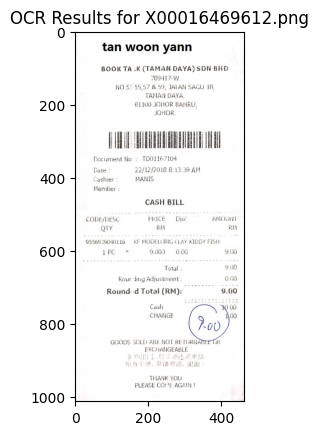

In [12]:
import sys
import os
import json
import cv2
import matplotlib.pyplot as plt
import pytesseract

pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

sys.path.append(os.path.abspath('..'))

from src.preprocessing import extract_ocr_from_xml

try:
    train_files = [f for f in os.listdir("../data/train") if f.endswith(('.png', '.jpg'))]
    if not train_files:
        print("Error: No images found in ../data/train. Did you run the split script?")
    else:
        sample_name = train_files[0]
        test_img = f"../data/train/{sample_name}"
        test_xml = f"../data/train/{os.path.splitext(sample_name)[0]}.xml"

        results = extract_ocr_from_xml(test_img, test_xml)

        print(f"Checking file: {sample_name}")
        print("Extracted Data:", json.dumps(results, indent=2))

        img = cv2.imread(test_img)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
        plt.title(f"OCR Results for {sample_name}")
        plt.show()

except Exception as e:
    print(f"An error occurred: {e}")